In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/sample_data/sales_data_with_discounts.csv")
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


In [7]:
# Descriptive Analytics for Numerical Columns
df.info
df.isnull().sum()

,0
Date,0
Day,0
SKU,0
City,0
Volume,0
BU,0
Brand,0
Model,0
Avg Price,0
Total Sales Value,0


In [8]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,15,12100,181500,11.654820,21153.498820,160346.501180
1,10,10100,101000,11.560498,11676.102961,89323.897039
2,7,16100,112700,9.456886,10657.910157,102042.089843
3,6,20100,120600,6.935385,8364.074702,112235.925298
4,3,8100,24300,17.995663,4372.946230,19927.053770


In [9]:
desc_stats = df[num_cols].describe().T
print(desc_stats)


                   count          mean           std         min          25%  \
Volume             450.0      5.066667      4.231602    1.000000     3.000000   
Avg Price          450.0  10453.433333  18079.904840  290.000000   465.000000   
Total Sales Value  450.0  33812.835556  50535.074173  400.000000  2700.000000   
Discount Rate (%)  450.0     15.155242      4.220602    5.007822    13.965063   
Discount Amount    450.0   3346.499424   4509.902963   69.177942   460.459304   
Net Sales Value    450.0  30466.336131  46358.656624  326.974801  2202.208645   

                           50%           75%            max  
Volume                4.000000      6.000000      31.000000  
Avg Price          1450.000000  10100.000000   60100.000000  
Total Sales Value  5700.000000  53200.000000  196400.000000  
Discount Rate (%)    16.577766     18.114718      19.992407  
Discount Amount     988.933733   5316.495427   25738.022194  
Net Sales Value    4677.788059  47847.912852  179507.479049 

In [10]:
for col in num_cols:
    print(f"Mode of {col}: {df[col].mode().values}")


Mode of Volume: [3]
Mode of Avg Price: [ 400  450  500 1300 8100]
Mode of Total Sales Value: [24300]
Mode of Discount Rate (%): [ 5.00782219  5.05521841  5.05980128  5.07212419  5.08410843  5.25211255
  5.41180219  5.42050666  5.42591053  5.46637934  5.48515667  5.51104232
  5.55371934  5.79480208  5.87067094  5.93508419  6.00819957  6.06619192
  6.09520144  6.1069307   6.17039789  6.2148882   6.26891381  6.32689169
  6.41523029  6.43991996  6.47330471  6.50871908  6.64259534  6.71045354
  6.81911066  6.84997564  6.85825457  6.93538533  7.1787259   7.20836295
  7.23384674  7.25669557  7.34187434  7.41010449  7.4213256   7.58459064
  7.62179096  7.6793856   7.73266709  7.74799088  7.78526825  7.80286089
  7.82377392  7.82635371  7.98881272  8.09708709  8.39446932  8.41262648
  8.41772966  8.4402058   8.44067883  8.46941228  8.49148617  8.53227792
  8.56924892  8.60107991  8.65822536  8.66804132  8.74130231  8.90713438
  8.97734337  9.01274999  9.05046838  9.05874649  9.08501516  9.08608

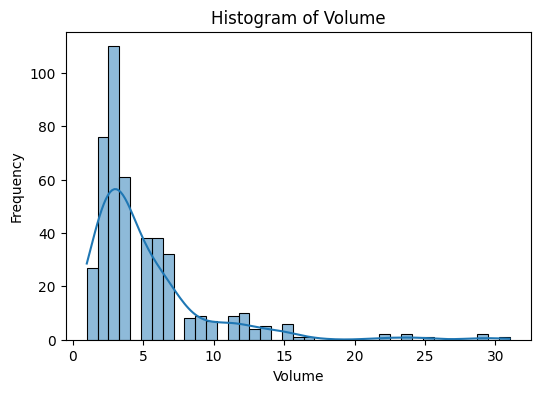

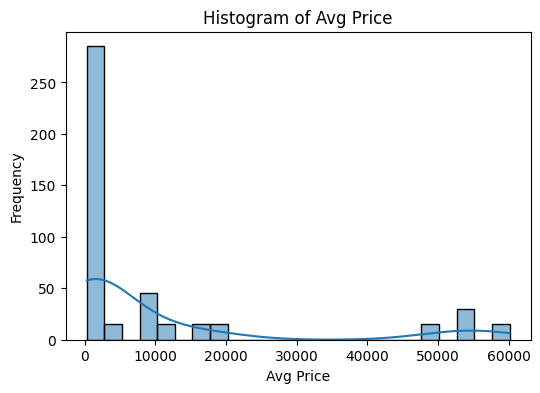

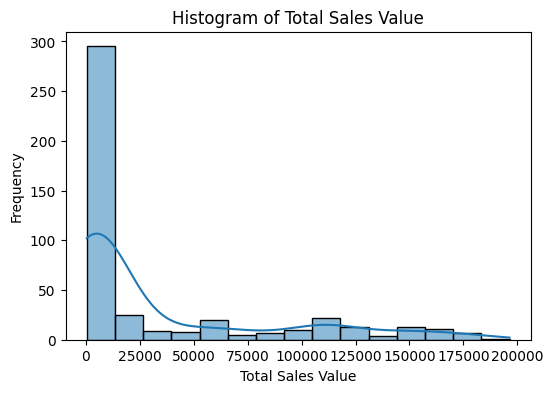

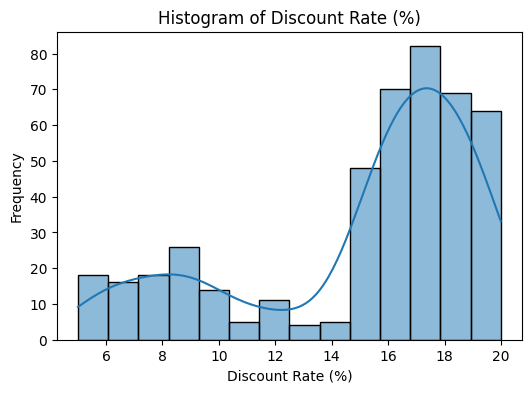

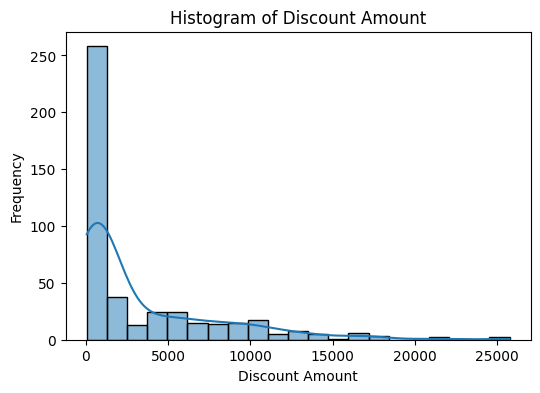

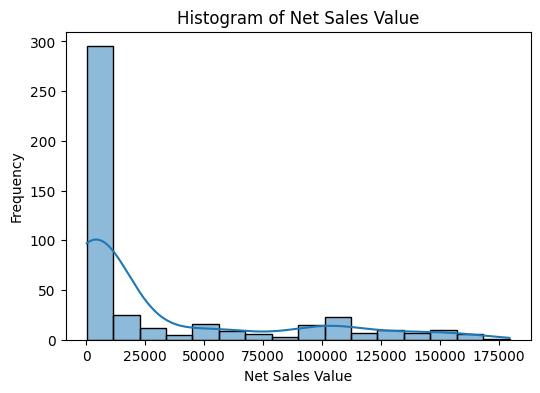

In [11]:
# Data Visualization

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


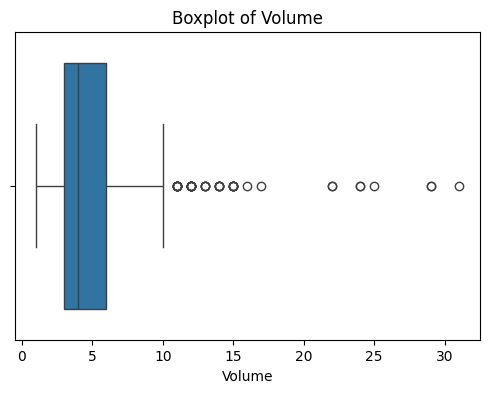

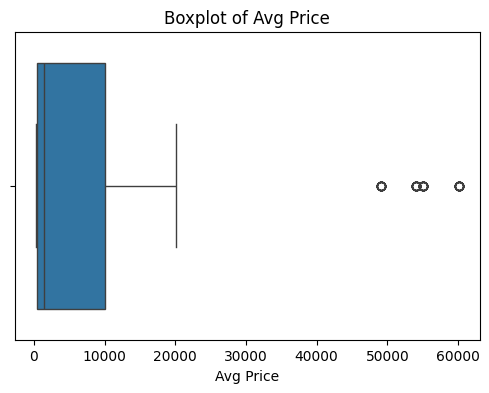

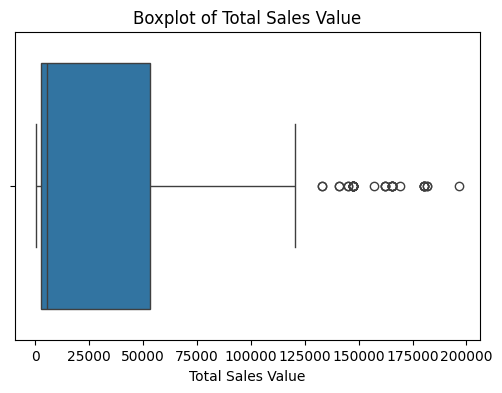

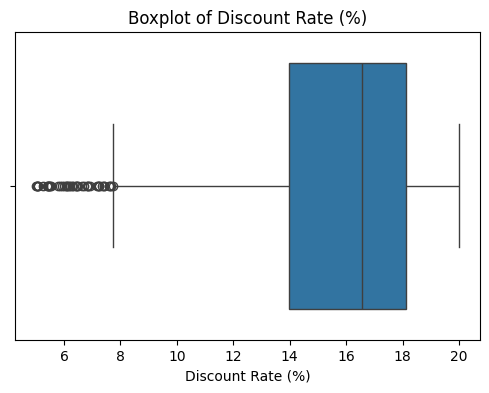

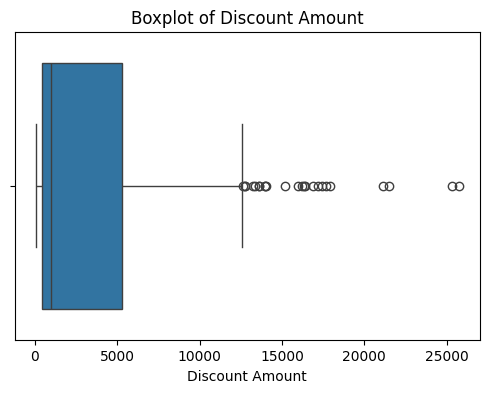

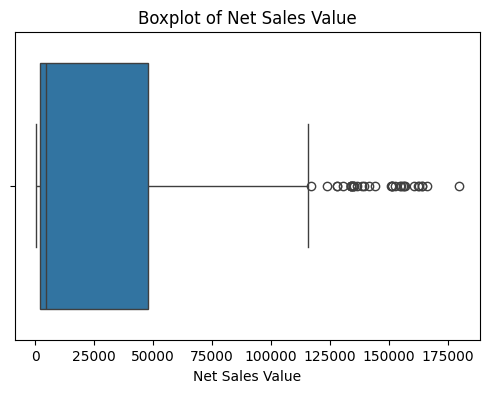

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


In [16]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols].head()


,Date,Day,SKU,City,BU,Brand,Model
0,01-04-2021,Thursday,M01,C,Mobiles,RealU,RU-10
1,01-04-2021,Thursday,M02,C,Mobiles,RealU,RU-9 Plus
2,01-04-2021,Thursday,M03,C,Mobiles,YouM,YM-99
3,01-04-2021,Thursday,M04,C,Mobiles,YouM,YM-99 Plus
4,01-04-2021,Thursday,M05,C,Mobiles,YouM,YM-98


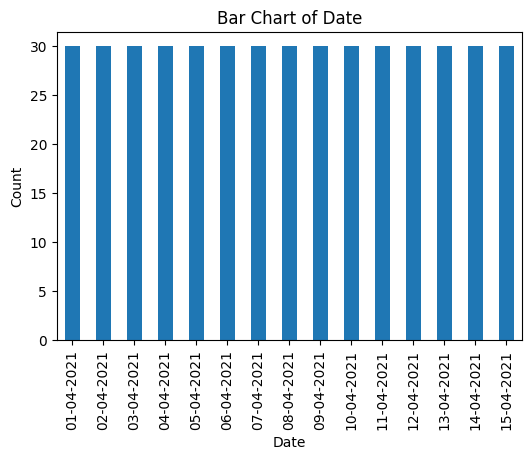

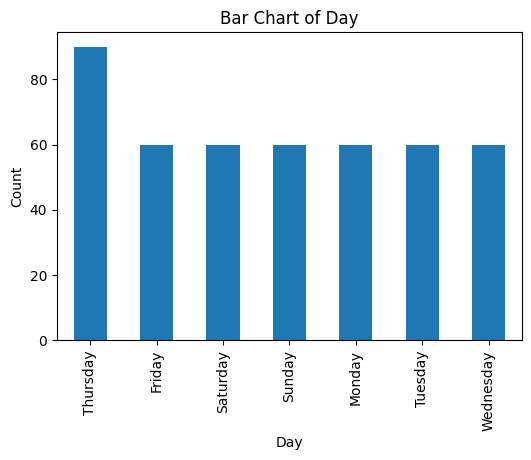

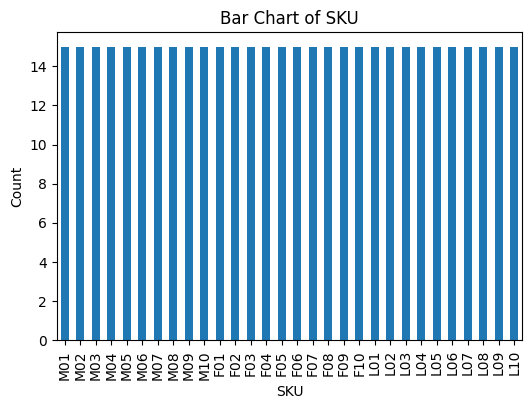

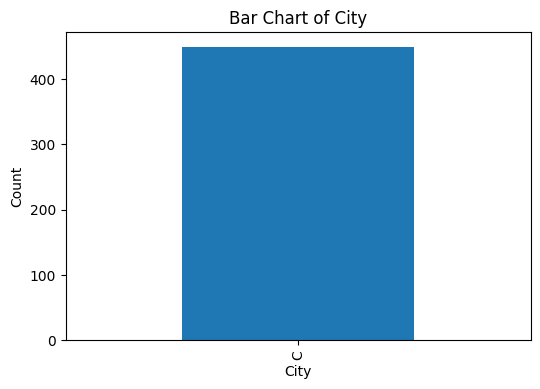

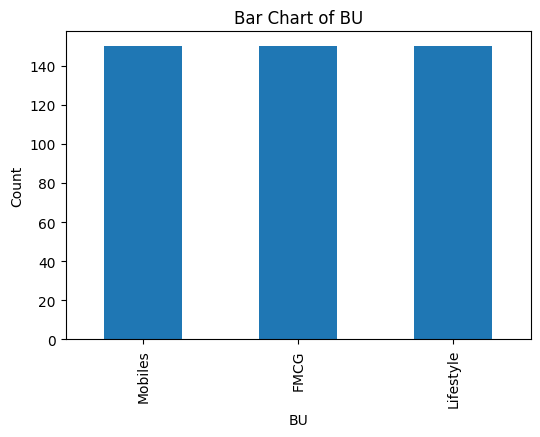

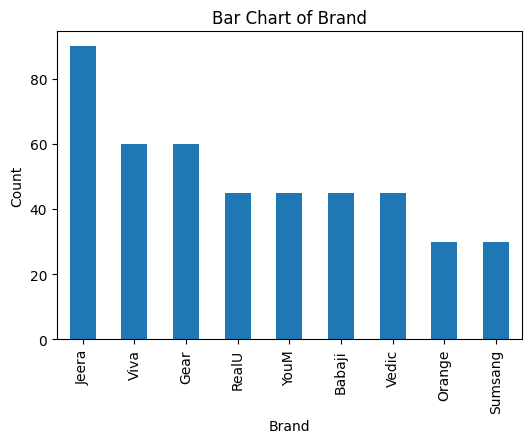

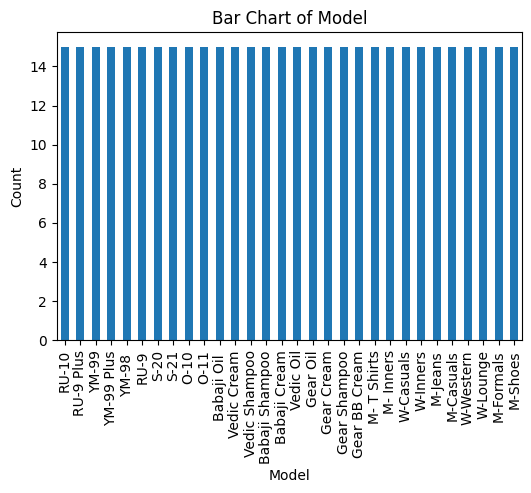

In [17]:
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Bar Chart of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()


# inference

Region column might show higher sales concentration in specific areas.

Category column could reveal best-selling product categories.

# Conclusion

1. The mean and median values helped understand the central trends of sales and profits.

2. Histograms revealed right skewness in sales and discount distributions.

3. Boxplots highlighted outliers, guiding data cleaning decisions.

4. Bar charts identified dominant categories and regional sales patterns.
